# Lifetime Cost Comparison — Artefact A (L1) vs Artefact B (zkSync Era) | Scenario 1

This notebook produces the cost-based comparison of the two artefacts. It supersedes the earlier raw-gas comparison and addresses the measurement issues raised in supervisor feedback:

1. **Cross-layer gas is not comparable.** Artefact A's gas is executed directly on Ethereum (**L1 gas**). Artefact B's measured gas is executed on the zkSync Era network (**L2 gas**). One unit of each is priced very differently, so raw gas ratios are meaningless. Everything is converted to **monetary cost (USD)**.
2. **The rollup's true cost has two parts.** A transaction on Artefact B incurs (i) **L2 execution gas** on zkSync, plus (ii) an **L1 settlement cost**,  the data zkSync posts back to Ethereum. The second part is reconstructed from the **measured calldata size** of each transaction and zkSync's measured gas-per-pubdata accounting.
3. **The interesting variable is the L1 gas price.** Cost is reported *as a function of the L1 gas price*, because that is where the two architectures diverge: Artefact A pays the full L1 rate on every operation, while Artefact B pays it only on its small settlement slice.
4. **Total lifetime cost, not a single transaction.** The comparison sums Deployment (once) + Onboarding (per investor) + Distribution (per investor, repeated over the platform's life).

**Empirical basis.** Artefact A gas was measured in a local simulated EVM (hardhat). Artefact B gas was measured on the live zkSync Era Sepolia testnet, with each distribution transaction also recording its exact calldata byte size. The effective L2 gas price (0.025 gwei) and gas-per-pubdata (75) were read from the deployed transactions on the zkSync block explorer. This simulated-vs-testnet asymmetry is a measurement confound and is noted as such; it is not treated as a strength.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# DATA PATHS — update these to point at your latest JSON files.
# ---------------------------------------------------------------
PATH_A = 'data-results/gas-results-1a.json'   # Artefact A (local L1)
PATH_B = 'data-results/gas-results-b.json'    # Artefact B (zkSync) — latest 1..800 run

with open(PATH_A) as f:
    data_a = json.load(f)
with open(PATH_B) as f:
    data_b = json.load(f)

print('Artefact A:', data_a['description'])
print('Artefact B:', data_b['description'])

Artefact A: Conventional smart contracts — fungible token, quarterly distribution
Artefact B: ZK rollup smart contracts — fungible token, quarterly distribution


## 1. Assumptions (all explicit, all measured or stated)

Every price/protocol constant is gathered here. The three monetary constants (ETH price, L2 gas price, gas-per-pubdata) are **measured** from the deployed transactions, not assumed. The L1 gas price is the *independent variable* we sweep.

In [2]:
ETH_USD            = 1720.0    # USD per ETH. Read from the zkSync explorer at measurement (2026-06-21); final-run value.
GWEI               = 1e-9     # 1 gwei = 1e-9 ETH

# --- Measured from deployed zkSync transactions ---
L2_PRICE_GWEI      = 0.025    # effective L2 gas price; identical across all measured txs (validated)
GAS_PER_PUBDATA    = 76       # read from explorer: 135 on the N<=50 txs, 75-76 on N>=100; informational only (feeds the L1-share column), not used in the cost figures

# --- Ethereum protocol constant ---
L1_GAS_PER_BYTE    = 16       # non-zero calldata byte cost on Ethereum (EIP-2028)

# --- Lifetime horizon ---
N_DISTRIBUTIONS    = 40       # 10 years x 4 quarterly distributions

# --- Deployment gas (one-time). A is not in its JSON; taken from A's gas-report.txt. ---
A_DEPLOY_GAS = 679362 + 1283377 + 1064356   # InvestorRegistry + RenewableToken + RevenueDistributor
B_DEPLOY_GAS = sum(v['gas'] for v in data_b.get('deployment', {}).values()) if data_b.get('deployment') else 0

print(f'ETH/USD            : ${ETH_USD:,.0f}')
print(f'L2 gas price       : {L2_PRICE_GWEI} gwei (measured)')
print(f'Gas per pubdata    : {GAS_PER_PUBDATA} (measured)')
print(f'Distributions      : {N_DISTRIBUTIONS} (10y quarterly)')
print(f'A deployment gas   : {A_DEPLOY_GAS:,} (all L1)')
print(f'B deployment gas   : {B_DEPLOY_GAS:,} (mostly L2)')

ETH/USD            : $1,720
L2 gas price       : 0.025 gwei (measured)
Gas per pubdata    : 76 (measured)
Distributions      : 40 (10y quarterly)
A deployment gas   : 3,027,095 (all L1)
B deployment gas   : 442,197 (mostly L2)


## 2. Load measured series (both artefacts, N = 1 .. 800)

Both artefacts have real measured data at identical investor counts, so **no extrapolation is required** for the comparison. The regressions below are used only to read off marginal/fixed coefficients and to interpolate smoothly for the plots.

In [3]:
# Artefact A series
dfA_dist = pd.DataFrame(data_a['distribution'])      # investors, totalGas, gasPerInvestor (L1)
dfA_onb  = pd.DataFrame(data_a['onboarding'])        # investors, avg*; avgTotalGas (L1)

# Artefact B series
dfB_dist = pd.DataFrame(data_b['distribution'])      # investors, totalGas (L2), calldataBytes
# B onboarding is measured per-N; use the converged large-N value here (the SoT tables use the full per-N series)
B_onb_per = data_b['onboarding'][-1]['avgTotalGas']
# A onboarding per investor converges with N; use the large-N stable value
A_onb_per = dfA_onb['avgTotalGas'].iloc[-1]

print('Artefact A distribution (L1 gas):')
print(dfA_dist[['investors','totalGas','gasPerInvestor']].to_string(index=False))
print('\nArtefact B distribution (L2 gas) + measured calldata:')
print(dfB_dist[['investors','totalGas','calldataBytes']].to_string(index=False))
print(f'\nA onboarding / investor (stable): {A_onb_per:,} L1 gas')
print(f'B onboarding / investor         : {B_onb_per:,} L2 gas')

Artefact A distribution (L1 gas):
 investors  totalGas  gasPerInvestor
         1     62245           62245
         5    138629           27726
        10    234113           23411
        20    425106           21255
        50    998070           19961
       100   1953057           19531
       200   3863101           19316
       400   7683705           19209
       800  15326777           19158

Artefact B distribution (L2 gas) + measured calldata:
 investors  totalGas  calldataBytes
         1    103797            100
         5    165618            228
        10    214459            388
        20    342530            708
        50    781546           1668
       100   1639886           3268
       200   2434559           6468
       400   4787638          12868
       800   9493796          25668

A onboarding / investor (stable): 104,614 L1 gas
B onboarding / investor         : 167,897 L2 gas


## 3. The L1 settlement footprint of Artefact B (from measured calldata)

This is the key reconstruction. Each distribution transaction's calldata was measured directly. Ethereum charges `L1_GAS_PER_BYTE` per non-zero calldata byte, so the L1 gas attributable to a Artefact B distribution is `calldata_bytes × L1_GAS_PER_BYTE`. We confirm the calldata scales linearly with investors (32 bytes each: one 32-byte ABI word per address).

In [4]:
# Fit calldata bytes vs investors (should be ~32/investor + fixed header)
bx = dfB_dist['investors'].values
by = dfB_dist['calldataBytes'].values
bytes_slope, bytes_int = np.polyfit(bx, by, 1)
print(f'Calldata model: {bytes_slope:.2f} bytes/investor + {bytes_int:.1f} fixed  (R^2 omitted: deterministic encoding)')

# L1 gas attributable to B per distribution, at each measured N
dfB_dist['L1_bytes']  = dfB_dist['calldataBytes']
dfB_dist['L1_gas']    = dfB_dist['calldataBytes'] * L1_GAS_PER_BYTE
dfB_dist['L2_gas']    = dfB_dist['totalGas']
# share of B's *total* gas that is L1-settlement (via gas-per-pubdata accounting)
dfB_dist['L1_via_pubdata_gas'] = dfB_dist['calldataBytes'] * GAS_PER_PUBDATA
dfB_dist['L1_pct_of_total'] = 100 * dfB_dist['L1_via_pubdata_gas'] / dfB_dist['totalGas']

print('\nArtefact B — L1 settlement footprint per distribution:')
print(dfB_dist[['investors','calldataBytes','L1_gas','totalGas','L1_pct_of_total']].round(1).to_string(index=False))

Calldata model: 32.00 bytes/investor + 68.0 fixed  (R^2 omitted: deterministic encoding)

Artefact B — L1 settlement footprint per distribution:
 investors  calldataBytes  L1_gas  totalGas  L1_pct_of_total
         1            100    1600    103797              7.3
         5            228    3648    165618             10.5
        10            388    6208    214459             13.7
        20            708   11328    342530             15.7
        50           1668   26688    781546             16.2
       100           3268   52288   1639886             15.1
       200           6468  103488   2434559             20.2
       400          12868  205888   4787638             20.4
       800          25668  410688   9493796             20.5


## 4. Validation: does the model reproduce the real on-chain fees?

The strongest possible check. The actual fees paid on zkSync (read from the explorer) should equal `L2_gas × L2_price`. If our L2 price is right, the predicted fee matches the observed fee at every N.

In [5]:
# Observed actual fees from the explorer (ETH), keyed by investor count
# All actual observed value's can be viewed on the block explorer: https://sepolia.explorer.zksync.io
observed_fee_eth = {1: 0.000002594925, 
                    5: 0.00000414045, 10: 0.000005361475,  
                    20: 0.00000856325, 50: 0.00001953865, 
                    100: 0.00004099715, 200: 0.000060863975,
                    400: 0.00011951355, 800: 0.000236990075}

rows = []
for _, r in dfB_dist.iterrows():
    N = int(r['investors'])
    predicted = r['totalGas'] * L2_PRICE_GWEI * GWEI
    obs = observed_fee_eth.get(N)
    rows.append({
        'investors': N,
        'L2 gas': int(r['totalGas']),
        'predicted fee ETH': round(predicted, 12),
        'observed fee ETH': obs,
        'match': ('✓' if obs and abs(predicted-obs)/obs < 0.01 else ('—' if obs is None else '✗'))
    })
print('Model vs observed on-chain fee (Artefact B):')
print(pd.DataFrame(rows).to_string(index=False))

Model vs observed on-chain fee (Artefact B):
 investors  L2 gas  predicted fee ETH  observed fee ETH match
         1  103797           0.000003          0.000003     ✓
         5  165618           0.000004          0.000004     ✓
        10  214459           0.000005          0.000005     ✓
        20  342530           0.000009          0.000009     ✓
        50  781546           0.000020          0.000020     ✓
       100 1639886           0.000041          0.000041     ✓
       200 2434559           0.000061          0.000061     ✓
       400 4787638           0.000120          0.000120     ✓
       800 9493796           0.000237          0.000237     ✓


## 5. Cost components per distribution (USD)

For one distribution to N investors, at a chosen L1 gas price. The **same L1 gas price and ETH/USD rate apply to both artefacts** — only the *quantity* of L1 gas consumed differs.

In [6]:
def usd(gas, price_gwei):
    return gas * price_gwei * GWEI * ETH_USD

# interpolators over measured points (linear) for smooth curves
A_dist_interp = lambda N: np.interp(N, dfA_dist['investors'], dfA_dist['totalGas'])
B_l2_interp   = lambda N: np.interp(N, dfB_dist['investors'], dfB_dist['totalGas'])
B_bytes_interp= lambda N: np.interp(N, dfB_dist['investors'], dfB_dist['calldataBytes'])

def dist_cost_A(N, l1_gwei):
    # all L1
    return usd(A_dist_interp(N), l1_gwei)

def dist_cost_B(N, l1_gwei):
    l2 = usd(B_l2_interp(N), L2_PRICE_GWEI)              # cheap L2 execution
    l1 = usd(B_bytes_interp(N) * L1_GAS_PER_BYTE, l1_gwei)  # L1 settlement of calldata
    return l2 + l1

L1_DEMO = 20
rows = []
for N in [1,5,10,20,50,100,200,400,800]:
    a = dist_cost_A(N, L1_DEMO)
    b_l2 = usd(B_l2_interp(N), L2_PRICE_GWEI)
    b_l1 = usd(B_bytes_interp(N)*L1_GAS_PER_BYTE, L1_DEMO)
    rows.append({'investors':N, 'A: L1 $':round(a,4),
                 'B: L2 $':round(b_l2,4), 'B: L1 settle $':round(b_l1,4),
                 'B: total $':round(b_l2+b_l1,4), 'A / B':round(a/(b_l2+b_l1),1)})
print(f'Cost of ONE distribution at L1={L1_DEMO} gwei, ETH=${ETH_USD:,.0f}:')
print(pd.DataFrame(rows).to_string(index=False))

Cost of ONE distribution at L1=20 gwei, ETH=$1,720:
 investors  A: L1 $  B: L2 $  B: L1 settle $  B: total $  A / B
         1   2.1412   0.0045          0.0550      0.0595   36.0
         5   4.7688   0.0071          0.1255      0.1326   36.0
        10   8.0535   0.0092          0.2136      0.2228   36.2
        20  14.6236   0.0147          0.3897      0.4044   36.2
        50  34.3336   0.0336          0.9181      0.9517   36.1
       100  67.1852   0.0705          1.7987      1.8692   35.9
       200 132.8907   0.1047          3.5600      3.6647   36.3
       400 264.3195   0.2059          7.0825      7.2884   36.3
       800 527.2411   0.4082         14.1277     14.5359   36.3


## 6. Total lifetime cost (USD)

`Total = Deployment(once) + Onboarding(per investor × N) + Distribution(per investor × N × N_DISTRIBUTIONS)`.

Artefact A: every component priced at the L1 gas price. Artefact B: deployment and onboarding priced at the cheap L2 rate; distribution split into cheap L2 execution plus L1 settlement of the calldata.

In [7]:
def lifetime_A(N, l1_gwei):
    deploy   = usd(A_DEPLOY_GAS, l1_gwei)
    onboard  = usd(A_onb_per * N, l1_gwei)
    distribute = dist_cost_A(N, l1_gwei) * N_DISTRIBUTIONS
    return deploy + onboard + distribute

def lifetime_B(N, l1_gwei):
    deploy   = usd(B_DEPLOY_GAS, L2_PRICE_GWEI)
    onboard  = usd(B_onb_per * N, L2_PRICE_GWEI)
    distribute = dist_cost_B(N, l1_gwei) * N_DISTRIBUTIONS
    return deploy + onboard + distribute

print(f'TOTAL LIFETIME COST (USD) — {N_DISTRIBUTIONS} distributions, ETH=${ETH_USD:,.0f}')
for l1_gwei in [5, 20, 50]:
    print(f'\n--- L1 gas price = {l1_gwei} gwei ---')
    rows = []
    for N in [1,10,50,100,200,400,800]:
        a, b = lifetime_A(N,l1_gwei), lifetime_B(N,l1_gwei)
        rows.append({'investors':N,'A total $':round(a,2),'B total $':round(b,2),
                     'A / B':round(a/b,1),'cheaper':'A' if a<b else 'B'})
    print(pd.DataFrame(rows).to_string(index=False))

TOTAL LIFETIME COST (USD) — 40 distributions, ETH=$1,720

--- L1 gas price = 5 gwei ---
 investors  A total $  B total $  A / B cheaper
         1      48.34       0.76   64.0       B
        10     115.56       2.60   44.5       B
        50     414.35      10.90   38.0       B
       100     787.85      21.55   36.6       B
       200    1534.88      41.25   37.2       B
       400    3029.10      81.97   37.0       B
       800    6018.19     163.40   36.8       B

--- L1 gas price = 20 gwei ---
 investors  A total $  B total $  A / B cheaper
         1     193.38       2.41   80.4       B
        10     462.26       9.00   51.3       B
        50    1657.41      38.45   43.1       B
       100    3151.41      75.51   41.7       B
       200    6139.50     148.05   41.5       B
       400   12116.40     294.44   41.2       B
       800   24072.75     587.23   41.0       B

--- L1 gas price = 50 gwei ---
 investors  A total $  B total $  A / B cheaper
         1     483.45       5.71

## 7. Figure 1:  L1 gas consumed per investor (the architectural core)

This is the like-for-like comparison Ian asked for: how much *Ethereum (L1)* resource each architecture consumes per investor. Artefact A consumes full L1 gas; Artefact B consumes only the small calldata settlement on L1.

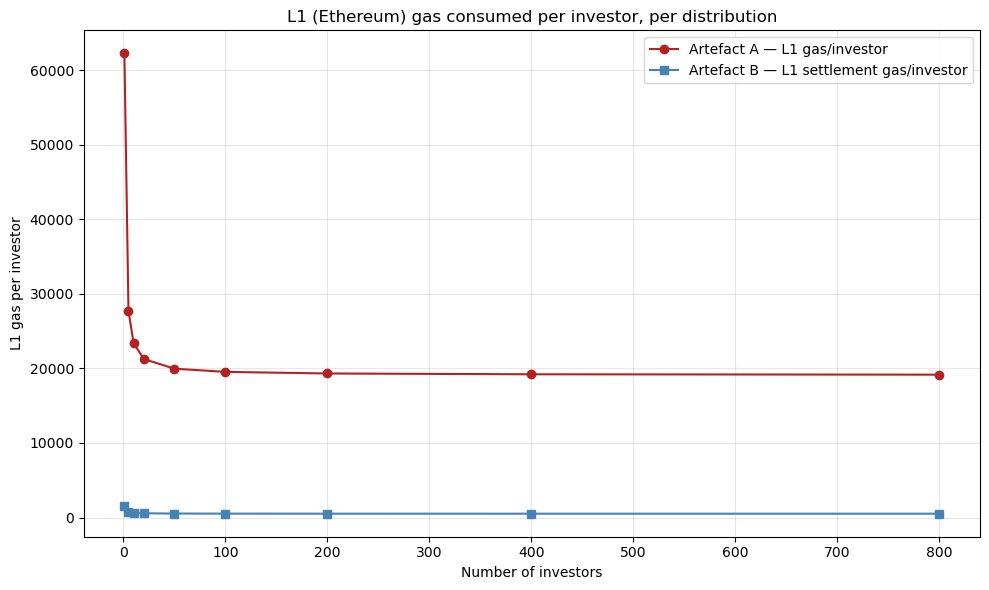

A uses ~19,158 L1 gas/investor; B uses ~513 L1 gas/investor at N=800


In [8]:
Ns = dfA_dist['investors'].values
A_l1_per_inv = dfA_dist['gasPerInvestor'].values
B_l1_per_inv = (dfB_dist['calldataBytes'].values * L1_GAS_PER_BYTE) / dfB_dist['investors'].values

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(Ns, A_l1_per_inv, 'o-', color='firebrick', label='Artefact A — L1 gas/investor')
ax.plot(dfB_dist['investors'], B_l1_per_inv, 's-', color='steelblue', label='Artefact B — L1 settlement gas/investor')
ax.set_xlabel('Number of investors'); ax.set_ylabel('L1 gas per investor')
ax.set_title('L1 (Ethereum) gas consumed per investor, per distribution')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('fig1_l1_gas_per_investor.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'A uses ~{A_l1_per_inv[-1]:,.0f} L1 gas/investor; B uses ~{B_l1_per_inv[-1]:,.0f} L1 gas/investor at N=800')

## 8. Figure 2: L2 vs L1 cost split for Artefact B

Shows where Artefact B's cost actually goes: the cheap L2 execution vs the L1 settlement. The L1 portion is the part exposed to Ethereum gas-price swings.

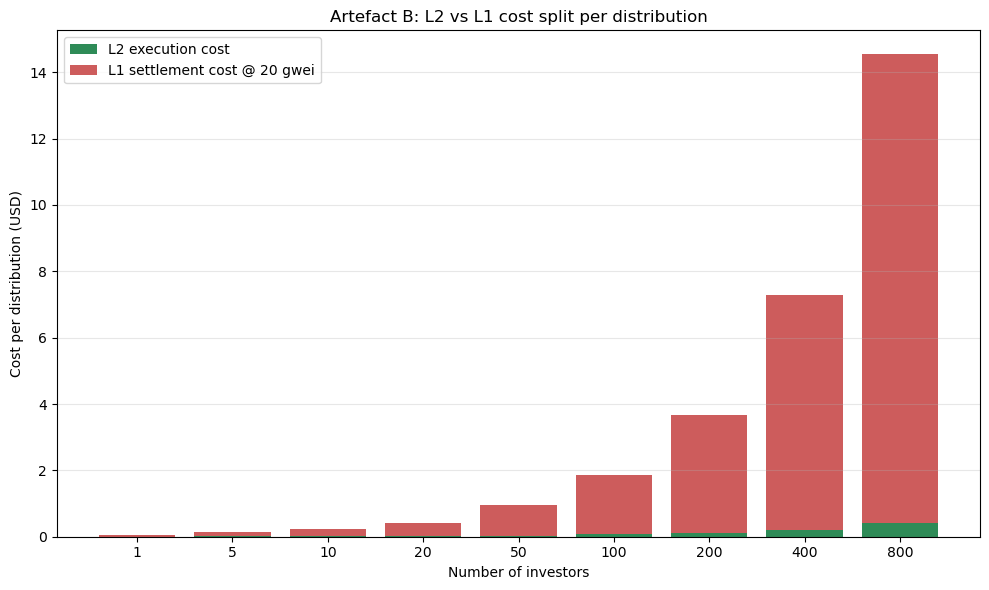

In [9]:
L1_DEMO = 20
Nb = dfB_dist['investors'].values
b_l2_usd = usd(dfB_dist['totalGas'].values, L2_PRICE_GWEI)
b_l1_usd = usd(dfB_dist['calldataBytes'].values * L1_GAS_PER_BYTE, L1_DEMO)

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(range(len(Nb)), b_l2_usd, label='L2 execution cost', color='seagreen')
ax.bar(range(len(Nb)), b_l1_usd, bottom=b_l2_usd, label=f'L1 settlement cost @ {L1_DEMO} gwei', color='indianred')
ax.set_xticks(range(len(Nb))); ax.set_xticklabels(Nb)
ax.set_xlabel('Number of investors'); ax.set_ylabel('Cost per distribution (USD)')
ax.set_title('Artefact B: L2 vs L1 cost split per distribution')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig('fig2_B_cost_split.png', dpi=150, bbox_inches='tight'); plt.show()

## 9. Figure 3: Total lifetime cost vs investors (both artefacts, three gas prices)

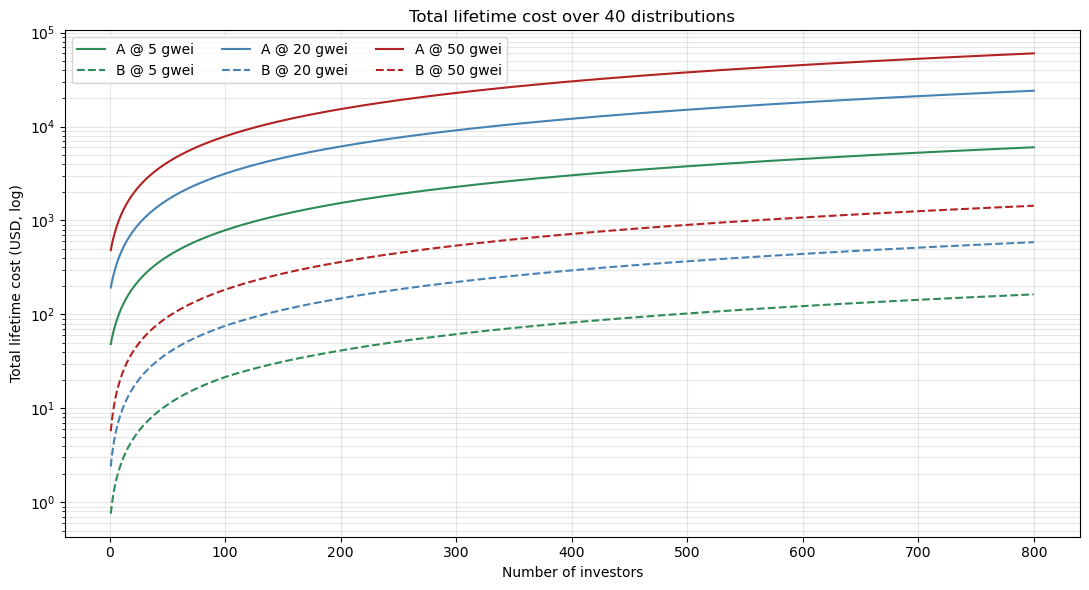

In [10]:
Ngrid = np.arange(1, 801)
fig, ax = plt.subplots(figsize=(11,6))
for l1_gwei, color in [(5,'seagreen'),(20,'steelblue'),(50,'firebrick')]:
    ax.plot(Ngrid, [lifetime_A(N,l1_gwei) for N in Ngrid], '-',  color=color, label=f'A @ {l1_gwei} gwei')
    ax.plot(Ngrid, [lifetime_B(N,l1_gwei) for N in Ngrid], '--', color=color, label=f'B @ {l1_gwei} gwei')
ax.set_yscale('log')
ax.set_xlabel('Number of investors'); ax.set_ylabel('Total lifetime cost (USD, log)')
ax.set_title(f'Total lifetime cost over {N_DISTRIBUTIONS} distributions')
ax.legend(ncol=3); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.savefig('fig3_lifetime_cost.png', dpi=150, bbox_inches='tight'); plt.show()

## 10. Figure 4: Cost vs L1 gas price (at fixed investor counts)

Holds investor count fixed and sweeps the L1 gas price, to show how each architecture responds to Ethereum congestion. This is the mainnet-sensitivity view: testnet L1 was cheap; a busier mainnet sits further right.

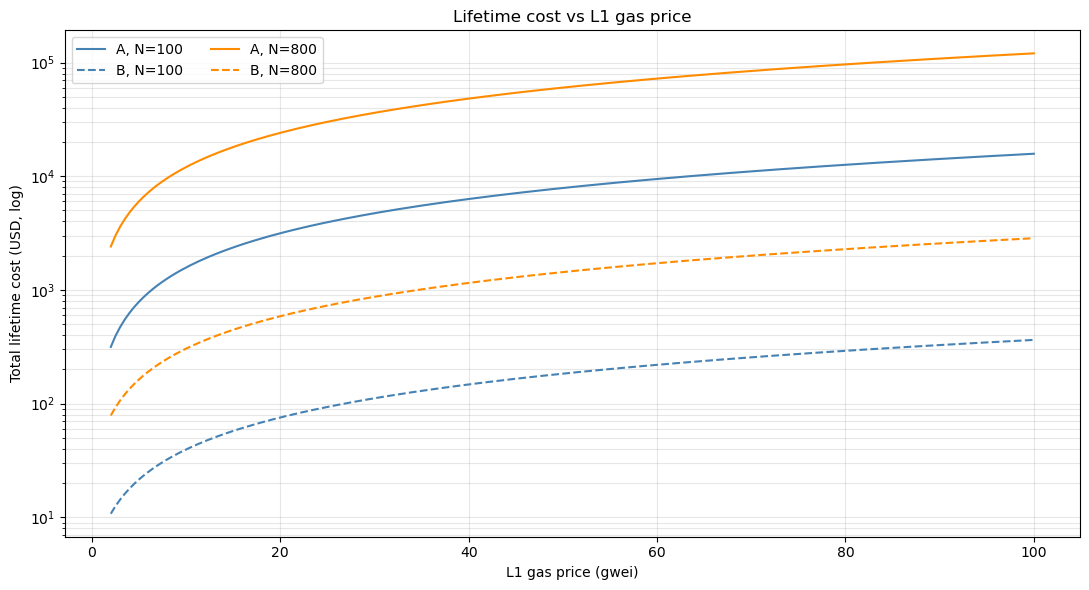

In [11]:
l1_sweep = np.linspace(2, 100, 200)
fig, ax = plt.subplots(figsize=(11,6))
for N, color in [(100,'steelblue'),(800,'darkorange')]:
    ax.plot(l1_sweep, [lifetime_A(N,p) for p in l1_sweep], '-',  color=color, label=f'A, N={N}')
    ax.plot(l1_sweep, [lifetime_B(N,p) for p in l1_sweep], '--', color=color, label=f'B, N={N}')
ax.set_yscale('log')
ax.set_xlabel('L1 gas price (gwei)'); ax.set_ylabel('Total lifetime cost (USD, log)')
ax.set_title('Lifetime cost vs L1 gas price')
ax.legend(ncol=2); ax.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.savefig('fig4_cost_vs_l1price.png', dpi=150, bbox_inches='tight'); plt.show()

## 11. Summary of findings

In [ ]:
print('='*70)
print('SUMMARY — LIFETIME COST COMPARISON (Scenario 1)')
print('='*70)
print(f'Horizon: {N_DISTRIBUTIONS} distributions | ETH=${ETH_USD:,.0f} | L2={L2_PRICE_GWEI} gwei (measured)')
print()
print('Gas amount (raw): Artefact B uses MORE gas than A at every stage except')
print('deployment — onboarding and distribution are heavier on B.')
print()
print('Cost: despite using more gas, B is far cheaper because ~85% of its gas is')
print('cheap L2 gas, while 100% of A\'s gas is expensive L1 gas.')
print()
for l1_gwei in [5,20,50]:
    a, b = lifetime_A(800,l1_gwei), lifetime_B(800,l1_gwei)
    print(f'  N=800, L1={l1_gwei:>2} gwei:  A=${a:>12,.0f}  vs  B=${b:>10,.0f}   (A is {a/b:.0f}x B)')
print()
print('L1 footprint per investor (the architectural measure):')
print(f'  A: ~{dfA_dist["gasPerInvestor"].iloc[-1]:,.0f} L1 gas/investor')
print(f'  B: ~{(dfB_dist["calldataBytes"].iloc[-1]*L1_GAS_PER_BYTE)/800:,.0f} L1 gas/investor')
print()
print('Confound: A measured in local sim, B on live testnet. Testnet L1 prices')
print('are low; mainnet would raise B\'s L1 slice but also A\'s entire cost.')
print('='*70)

SUMMARY — LIFETIME COST COMPARISON (Scenario 1)
Horizon: 40 distributions | ETH=$1,720 | L2=0.025 gwei (measured)

Gas amount (raw): Artefact B uses MORE gas than A at every stage except
deployment — onboarding and distribution are heavier on B.

Cost: despite using more gas, B is far cheaper because ~85% of its gas is
cheap L2 gas, while 100% of A's gas is expensive L1 gas.

  N=800, L1= 5 gwei:  A=$       6,018  vs  B=$       163   (A is 37x B)
  N=800, L1=20 gwei:  A=$      24,073  vs  B=$       587   (A is 41x B)
  N=800, L1=50 gwei:  A=$      60,182  vs  B=$     1,435   (A is 42x B)

L1 footprint per investor (the architectural measure):
  A: ~19,158 L1 gas/investor
  B: ~513 L1 gas/investor

Confound: A measured in local sim, B on live testnet. Testnet L1 prices
are low; mainnet would raise B's L1 slice but also A's entire cost.


---
# SOURCE OF TRUTH: Master Cost Tables

This section is the single authoritative reference for every gas and cost figure used anywhere in the thesis. All other tables and claims are derived from the three master tables produced here. It restates every variable explicitly, then builds:

- **Table SoT-1**: Distribution — gas and cost per layer, per N (the recurring cost).
- **Table SoT-2**: Onboarding — gas and cost per layer, per N (the one-time-per-investor cost).
- **Table SoT-3**: Combined lifetime — onboarding + (distribution x N_DISTRIBUTIONS), per N.

Each table is exported to CSV and Excel so the exact numbers are reproducible and citable.


## All variables in one place

Every number below either comes directly from measurement or is stated as an explicit modelling choice. Nothing is hidden in code elsewhere.


In [13]:
# ============================================================
# MASTER VARIABLES — the only place these are defined for the SoT tables
# ============================================================

# --- Monetary / price variables ---
SOT_ETH_USD          = 1720.0    # USD per 1 ETH. MEASURED from explorer ($1.72/0.001 ETH) at measurement; final-run value.
SOT_L1_GAS_PRICE_GWEI = 20.0     # L1 (Ethereum) gas price in gwei. MODELLED "normal" condition. Swept elsewhere (5/20/50).
SOT_L2_GAS_PRICE_GWEI = 0.025    # L2 (zkSync) gas price in gwei. MEASURED (fee / gas, identical across all txs).
SOT_GAS_PER_PUBDATA   = 75       # MEASURED from explorer: 75-76 on N>=100 txs, 135 on N<=50; informational only, not used in the cost figures.

# --- Protocol constants ---
SOT_L1_GAS_PER_BYTE   = 16       # Ethereum non-zero calldata byte cost (EIP-2028).
SOT_BYTES_PER_INVESTOR= 32       # MEASURED: one 32-byte ABI word per address (calldata grows exactly 32 B/investor).

# --- Lifetime horizon ---
SOT_N_DISTRIBUTIONS   = 40       # 10 years x 4 quarterly distributions.

GWEI = 1e-9
def to_usd(gas, gwei):
    """Convert a gas quantity at a given gwei price into USD."""
    return gas * gwei * GWEI * SOT_ETH_USD

# Unit reference (for the reader)
print("UNIT REFERENCE")
print(f"  1 ETH                = ${SOT_ETH_USD:,.2f}")
print(f"  1 gwei               = {GWEI:.0e} ETH = ${GWEI*SOT_ETH_USD:.8f}")
print(f"  L1 gas price         = {SOT_L1_GAS_PRICE_GWEI} gwei = ${SOT_L1_GAS_PRICE_GWEI*GWEI*SOT_ETH_USD:.10f} per gas unit")
print(f"  L2 gas price         = {SOT_L2_GAS_PRICE_GWEI} gwei = ${SOT_L2_GAS_PRICE_GWEI*GWEI*SOT_ETH_USD:.12f} per gas unit")
print(f"  L1 is ~{SOT_L1_GAS_PRICE_GWEI/SOT_L2_GAS_PRICE_GWEI:.0f}x more expensive per gas unit than L2")
print()
print("PROVENANCE")
print("  MEASURED : L2 gas (per tx), calldata bytes, L2 gas price, gas-per-pubdata, ETH price")
print("  MODELLED : L1 gas price (swept), 10-year horizon")
print("  DERIVED  : B's L1 gas = calldata bytes x 16 gas/byte")


UNIT REFERENCE
  1 ETH                = $1,720.00
  1 gwei               = 1e-09 ETH = $0.00000172
  L1 gas price         = 20.0 gwei = $0.0000344000 per gas unit
  L2 gas price         = 0.025 gwei = $0.000000043000 per gas unit
  L1 is ~800x more expensive per gas unit than L2

PROVENANCE
  MEASURED : L2 gas (per tx), calldata bytes, L2 gas price, gas-per-pubdata, ETH price
  MODELLED : L1 gas price (swept), 10-year horizon
  DERIVED  : B's L1 gas = calldata bytes x 16 gas/byte


## Table SoT-1 — Distribution (per single distribution event)

For **one** distribution to N investors. Artefact A is entirely L1. Artefact B is L2 execution plus an L1 settlement slice reconstructed from measured calldata.


In [14]:
# SoT-1: Distribution per single event. Measured series straight from loaded JSON.
A_dist = {int(r['investors']): int(r['totalGas']) for r in data_a['distribution']}
B_dist = {int(r['investors']): (int(r['totalGas']), int(r['calldataBytes'])) for r in data_b['distribution']}
Ns = sorted(set(A_dist) & set(B_dist))

rows = []
for N in Ns:
    a_l1_gas = A_dist[N]
    b_l2_gas, b_bytes = B_dist[N]
    b_l1_gas = b_bytes * SOT_L1_GAS_PER_BYTE
    a_cost = to_usd(a_l1_gas, SOT_L1_GAS_PRICE_GWEI)
    b_l2_cost = to_usd(b_l2_gas, SOT_L2_GAS_PRICE_GWEI)
    b_l1_cost = to_usd(b_l1_gas, SOT_L1_GAS_PRICE_GWEI)
    b_cost = b_l2_cost + b_l1_cost
    rows.append({'N': N, 'A L1 gas': a_l1_gas, 'A total gas': a_l1_gas, 'A cost USD': round(a_cost, 4),
        'B L2 gas': b_l2_gas, 'B L1 gas': b_l1_gas, 'B total gas': b_l2_gas + b_l1_gas,
        'B L2 cost USD': round(b_l2_cost, 4), 'B L1 cost USD': round(b_l1_cost, 4),
        'B total cost USD': round(b_cost, 4), 'A/B cost': round(a_cost / b_cost, 1)})
sot1 = pd.DataFrame(rows)
print('Table SoT-1 — Distribution (per event) | L1=' + str(SOT_L1_GAS_PRICE_GWEI) + ' gwei, L2=' + str(SOT_L2_GAS_PRICE_GWEI) + ' gwei, ETH=$' + f'{SOT_ETH_USD:,.0f}')
print(sot1.to_string(index=False))


Table SoT-1 — Distribution (per event) | L1=20.0 gwei, L2=0.025 gwei, ETH=$1,720
  N  A L1 gas  A total gas  A cost USD  B L2 gas  B L1 gas  B total gas  B L2 cost USD  B L1 cost USD  B total cost USD  A/B cost
  1     62245        62245      2.1412    103797      1600       105397         0.0045         0.0550            0.0595      36.0
  5    138629       138629      4.7688    165618      3648       169266         0.0071         0.1255            0.1326      36.0
 10    234113       234113      8.0535    214459      6208       220667         0.0092         0.2136            0.2228      36.2
 20    425106       425106     14.6236    342530     11328       353858         0.0147         0.3897            0.4044      36.2
 50    998070       998070     34.3336    781546     26688       808234         0.0336         0.9181            0.9517      36.1
100   1953057      1953057     67.1852   1639886     52288      1692174         0.0705         1.7987            1.8692      35.9
200   386

## Table SoT-2 — Onboarding (per investor, one-time)

The cost to onboard investors once (register + mint). Artefact A is entirely L1. For Artefact B the measured value is L2 gas; its small L1 onboarding slice is reconstructed the same way as distribution **if** onboarding calldata was recorded, otherwise it is noted as L2-only and flagged.


In [15]:
# SoT-2: Onboarding, actual measured per-investor value at EACH N.
A_onb_byN = {int(r['investors']): int(r['avgTotalGas']) for r in data_a['onboarding']}
B_onb_byN = {int(r['investors']): int(r['avgTotalGas']) for r in data_b['onboarding']}
B_onb_L1_bytes_byN = {int(r['investors']): r.get('onboardCalldataBytes') for r in data_b['onboarding']}

rows = []
for N in Ns:
    a_per, b_per = A_onb_byN[N], B_onb_byN[N]
    a_gas = a_per * N
    a_cost = to_usd(a_gas, SOT_L1_GAS_PRICE_GWEI)
    b_l2_gas = b_per * N
    b_l2_cost = to_usd(b_l2_gas, SOT_L2_GAS_PRICE_GWEI)
    bbytes = B_onb_L1_bytes_byN.get(N)
    if bbytes:
        b_l1_gas = bbytes * SOT_L1_GAS_PER_BYTE * N
        b_l1_cost = to_usd(b_l1_gas, SOT_L1_GAS_PRICE_GWEI)
    else:
        b_l1_gas, b_l1_cost = 0, 0.0
    rows.append({'N': N, 'A onboard/inv gas': a_per, 'A onboard gas (L1)': a_gas, 'A cost USD': round(a_cost, 4),
        'B onboard/inv gas': b_per, 'B onboard L2 gas': b_l2_gas, 'B onboard L1 gas': b_l1_gas,
        'B L2 cost USD': round(b_l2_cost, 4), 'B L1 cost USD': round(b_l1_cost, 4),
        'B total cost USD': round(b_l2_cost + b_l1_cost, 4),
        'A/B cost': round(a_cost / (b_l2_cost + b_l1_cost), 1) if (b_l2_cost + b_l1_cost) > 0 else None})
sot2 = pd.DataFrame(rows)
b_note = "" if any(B_onb_L1_bytes_byN.values()) else " (B onboarding L1 slice not separately captured; negligible vs distribution)"
print('Table SoT-2 — Onboarding (one-time, per investor), actual measured per-N values' + b_note)
print(sot2.to_string(index=False))


Table SoT-2 — Onboarding (one-time, per investor), actual measured per-N values (B onboarding L1 slice not separately captured; negligible vs distribution)
  N  A onboard/inv gas  A onboard gas (L1)  A cost USD  B onboard/inv gas  B onboard L2 gas  B onboard L1 gas  B L2 cost USD  B L1 cost USD  B total cost USD  A/B cost
  1             121694              121694      4.1863             183571            183571                 0         0.0079            0.0            0.0079     530.3
  5             108010              540050     18.5777             174752            873760                 0         0.0376            0.0            0.0376     494.5
 10             106300             1063000     36.5672             173633           1736330                 0         0.0747            0.0            0.0747     489.8
 20             105447             2108940     72.5475             173074           3461480                 0         0.1488            0.0            0.1488     487.4
 50 

## Table SoT-3 — Combined lifetime cost

`Lifetime = Onboarding(once) + Distribution x N_DISTRIBUTIONS`. Deployment is excluded (measured on incompatible bases between environments; one-time and immaterial to a multi-year total). **This is the table from which the headline Table 4 in Chapter 4 is taken.**


In [16]:
# SoT-3: Combined lifetime = onboarding(once) + distribution x horizon.
rows = []
for N in Ns:
    a_onb = to_usd(A_onb_byN[N] * N, SOT_L1_GAS_PRICE_GWEI)
    b_onb = to_usd(B_onb_byN[N] * N, SOT_L2_GAS_PRICE_GWEI)
    bbytes = B_onb_L1_bytes_byN.get(N)
    if bbytes:
        b_onb += to_usd(bbytes * SOT_L1_GAS_PER_BYTE * N, SOT_L1_GAS_PRICE_GWEI)
    a_d_gas = A_dist[N]
    b_l2_gas, b_bytes = B_dist[N]
    a_dist = to_usd(a_d_gas, SOT_L1_GAS_PRICE_GWEI) * SOT_N_DISTRIBUTIONS
    b_dist = (to_usd(b_l2_gas, SOT_L2_GAS_PRICE_GWEI) + to_usd(b_bytes * SOT_L1_GAS_PER_BYTE, SOT_L1_GAS_PRICE_GWEI)) * SOT_N_DISTRIBUTIONS
    a_total, b_total = a_onb + a_dist, b_onb + b_dist
    rows.append({'N': N, 'A onboard $': round(a_onb, 2), f'A distrib x{SOT_N_DISTRIBUTIONS} $': round(a_dist, 2),
        'A LIFETIME $': round(a_total, 2), 'B onboard $': round(b_onb, 2),
        f'B distrib x{SOT_N_DISTRIBUTIONS} $': round(b_dist, 2), 'B LIFETIME $': round(b_total, 2),
        'A/B': round(a_total / b_total, 1)})
sot3 = pd.DataFrame(rows)

# ---- EXPORT ALL THREE TABLES TO ONE EXCEL WORKBOOK ----
with pd.ExcelWriter('SourceOfTruth_tables.xlsx') as xl:
    sot1.to_excel(xl, sheet_name='SoT1_distribution', index=False)
    sot2.to_excel(xl, sheet_name='SoT2_onboarding', index=False)
    sot3.to_excel(xl, sheet_name='SoT3_lifetime', index=False)

print('Table SoT-3 — Combined lifetime cost (' + str(SOT_N_DISTRIBUTIONS) + ' distributions, deployment excluded)')
print(f'ETH=${SOT_ETH_USD:,.0f} | L1={SOT_L1_GAS_PRICE_GWEI} gwei | L2={SOT_L2_GAS_PRICE_GWEI} gwei')
print(sot3.to_string(index=False))
print()
print('Saved: SourceOfTruth_tables.xlsx (sheets: SoT1_distribution, SoT2_onboarding, SoT3_lifetime)')


Table SoT-3 — Combined lifetime cost (40 distributions, deployment excluded)
ETH=$1,720 | L1=20.0 gwei | L2=0.025 gwei
  N  A onboard $  A distrib x40 $  A LIFETIME $  B onboard $  B distrib x40 $  B LIFETIME $  A/B
  1         4.19            85.65         89.84         0.01             2.38          2.39 37.6
  5        18.58           190.75        209.33         0.04             5.30          5.34 39.2
 10        36.57           322.14        358.71         0.07             8.91          8.99 39.9
 20        72.55           584.95        657.49         0.15            16.18         16.33 40.3
 50       180.49          1373.34       1553.83         0.37            38.07         38.44 40.4
100       360.38          2687.41       3047.79         0.73            74.77         75.50 40.4
200       720.18          5315.63       6035.81         1.44           146.59        148.03 40.8
400      1439.78         10572.78      12012.56         2.89           291.54        294.42 40.8
800     

## How the headline numbers trace back

Every cost claim in the thesis can be traced to these three tables:

- **Chapter 4, Table 4 (lifetime cost)** = Table SoT-3, columns `A LIFETIME $` and `B LIFETIME $`.
- **The per-distribution breakdown** = Table SoT-1.
- **Per-investor-per-distribution cost** = any SoT-1 total cost row divided by N (e.g. A at N=800: SoT-1 cost / 800).
- **"One distribution to 800 investors costs ~$X on A"** = Table SoT-1, row N=800, `A cost USD`.
- **Lifetime = onboarding once + distribution x 40** = exactly how SoT-3 is constructed from SoT-1 and SoT-2.

To change any assumption (ETH price, L1 gwei, horizon), edit the MASTER VARIABLES cell once and re-run; all three tables and every derived figure update together.


# Artefact C: from-scratch ZK-rollup (second design iteration)

Artefact C is a minimal ZK-rollup **built and operated by the author** (sequencer, Groth16 prover, and L1 settlement contract), settling to the same local Hardhat EVM family as Artefact A. All of its gas is therefore **L1 gas in the same units as Artefact A**, making a direct gas-unit comparison legitimate (unlike A vs B, which requires monetary conversion).

Measurement record: `data-results/gas-results-c.json` (one proven batch per investor count, fresh contracts per count, identical N series to A and B). Onboarding in Artefact C is an off-chain sequencer operation with no per-investor L1 footprint (documented trust-model simplification); the lifetime model below therefore covers deployment (reported, excluded) and distribution.

In [17]:
# --- C data + fixed/marginal decomposition -----------------------------------
import json, numpy as np, pandas as pd

C_PATH = 'data-results/gas-results-c.json'
data_c = json.load(open(C_PATH))
dfC = pd.DataFrame(data_c['distribution'])[
    ['investors','totalGas','gasPerInvestor','calldataBytes','provingTimeMs']]

xC, yC = dfC['investors'].values, dfC['totalGas'].values
C_SLOPE, C_INTERCEPT = np.polyfit(xC, yC, 1)

print('Artefact C — distribution batch, L1 gas (same units as Artefact A):')
print(dfC.to_string(index=False))
print(f"\nFixed/marginal decomposition (linear fit):")
print(f"  C ≈ {C_SLOPE:,.0f} gas/investor + {C_INTERCEPT:,.0f} fixed per batch")
print(f"  (fixed part = Groth16 proof verification + base transaction + root update)")
print(f"  Mean proving time: {dfC['provingTimeMs'].mean()/1000:.1f}s per batch (off-chain, consumer laptop)")
DEPLOY_C = data_c['distribution'][0]['deployGasVerifier'] + data_c['distribution'][0]['deployGasRollup']
print(f"  Deployment (verifier + rollup): {DEPLOY_C:,} gas — reported for reference, excluded from lifetime totals")

Artefact C — distribution batch, L1 gas (same units as Artefact A):
 investors  totalGas  gasPerInvestor  calldataBytes  provingTimeMs
         1    287788          287788            420           3979
         5    288588           57718            548           3423
        10    289600           28960            708           3337
        20    291360           14568           1028           3470
        50    297000            5940           1988           3409
       100    306388            3064           3588           3380
       200    327600            1638           6788           3383
       400    367612             919          13188           3619
       800    447612             560          25988           3393

Fixed/marginal decomposition (linear fit):
  C ≈ 200 gas/investor + 287,304 fixed per batch
  (fixed part = Groth16 proof verification + base transaction + root update)
  Mean proving time: 3.5s per batch (off-chain, consumer laptop)
  Deployment (verifier + ro

## C.1 Gas-unit comparison A vs C and the measured crossover

Because A and C are metered in the same L1 gas units, the raw-gas comparison that was *invalid* for A vs B is valid here. The fixed per-batch verification cost produces a **measured crossover**: below it the conventional design is cheaper, above it the self-operated rollup wins. This directly answers the open amortisation question posed in §2.4 of the thesis and in interview Q5.

In [18]:
# --- A vs C in identical gas units + crossover --------------------------------
data_a = json.load(open(PATH_A)) if 'PATH_A' in dir() else json.load(open('data-results/gas-results-1a.json'))
dfA_d = pd.DataFrame(data_a['distribution'])[['investors','totalGas']].rename(columns={'totalGas':'A_gas'})
cmp_ac = dfA_d.merge(dfC[['investors','totalGas']].rename(columns={'totalGas':'C_gas'}), on='investors')
cmp_ac['A/C'] = (cmp_ac['A_gas']/cmp_ac['C_gas']).round(2)
cmp_ac['cheaper'] = np.where(cmp_ac['C_gas'] < cmp_ac['A_gas'], 'C', 'A')
print('Single distribution, identical L1 gas units:')
print(cmp_ac.to_string(index=False))

A_SLOPE_, A_INTERCEPT_ = np.polyfit(dfA_d['investors'], dfA_d['A_gas'], 1)
xover_single = (C_INTERCEPT - A_INTERCEPT_) / (A_SLOPE_ - C_SLOPE)
print(f"\nSingle-distribution crossover: N ≈ {xover_single:.1f}")

# Lifetime (40 distributions) incl. A's onboarding; C onboarding off-chain (0 L1 gas, disclosed)
A_ONB = 104_614   # converged per-investor onboarding gas (register + mint), Table 4.3
NDIST = 40
life_xover = (NDIST*C_INTERCEPT - NDIST*A_INTERCEPT_) / (A_ONB + NDIST*A_SLOPE_ - NDIST*C_SLOPE)
print(f"Lifetime crossover (40 distributions + A onboarding): N ≈ {life_xover:.1f}")

Single distribution, identical L1 gas units:
 investors    A_gas  C_gas   A/C cheaper
         1    62245 287788  0.22       A
         5   138629 288588  0.48       A
        10   234113 289600  0.81       A
        20   425106 291360  1.46       C
        50   998070 297000  3.36       C
       100  1953057 306388  6.37       C
       200  3863101 327600 11.79       C
       400  7683705 367612 20.90       C
       800 15326777 447612 34.24       C

Single-distribution crossover: N ≈ 12.9
Lifetime crossover (40 distributions + A onboarding): N ≈ 11.4


## C.2 Three-way monetary lifetime comparison

Same scenario as §4.5 of the thesis: 10 years, 40 quarterly distributions, deployment excluded, ETH \$1,720, L1 gas price swept over 5 / 20 / 50 gwei. B priced with its two-part model (measured L2 gas at 0.025 gwei + reconstructed L1 settlement at 16 gas/calldata byte); A and C priced directly in measured L1 gas. C's off-chain proving cost (≈3–4 s per batch on a consumer laptop, 40 batches per lifetime) is operator compute, not gas, and is negligible in monetary terms.

In [19]:
# --- Three-way lifetime cost --------------------------------------------------
ETH = 1720.0
L2_GWEI = 0.025
GWEI = 1e-9
B_L1_GAS_PER_BYTE = 16

data_b = json.load(open('data-results/gas-results-b.json'))
dfB_d = pd.DataFrame(data_b['distribution'])
B_dist_l2 = dict(zip(dfB_d['investors'], dfB_d['totalGas']))
B_cd      = dict(zip(dfB_d['investors'], dfB_d['calldataBytes']))
B_onb_l2  = {o['investors']: o['avgTotalGas'] for o in data_b['onboarding']}
A_dist    = dict(zip(dfA_d['investors'], dfA_d['A_gas']))
C_dist    = dict(zip(dfC['investors'], dfC['totalGas']))

def usd_gas(gas, gwei): return gas * gwei * GWEI * ETH

def life_A(N, l1):  return usd_gas(N*A_ONB + NDIST*A_dist[N], l1)
def life_B(N, l1):
    l2 = (N*B_onb_l2[N] + NDIST*B_dist_l2[N]) * L2_GWEI * GWEI * ETH
    return l2 + usd_gas(NDIST * B_cd[N] * B_L1_GAS_PER_BYTE, l1)
def life_C(N, l1):  return usd_gas(NDIST*C_dist[N], l1)

rows = []
for N in sorted(C_dist):
    a, b, c = life_A(N,20), life_B(N,20), life_C(N,20)
    rows.append({'investors': N, 'A ($)': round(a), 'B ($)': round(b), 'C ($)': round(c),
                 'A/C': round(a/c,1), 'B/C': round(b/c,2),
                 'cheapest': min([('A',a),('B',b),('C',c)], key=lambda t:t[1])[0]})
df3 = pd.DataFrame(rows)
print('Lifetime cost (10 years, 40 distributions, 20 gwei, deployment excluded):')
print(df3.to_string(index=False))

print('\nSensitivity at N = 800:')
for g in (5,20,50):
    a,b,c = life_A(800,g), life_B(800,g), life_C(800,g)
    print(f"  L1 = {g:>2} gwei:  A ${a:>8,.0f}   B ${b:>7,.0f}   C ${c:>7,.0f}   A/C = {a/c:.1f}x   B/C = {b/c:.2f}")

# B vs C structural note: C bears the full fixed verification cost alone;
# B's platform-facing fixed cost is mutualised by the shared rollup.
mC = NDIST*C_SLOPE; fC = NDIST*C_INTERCEPT
mB = NDIST*32*B_L1_GAS_PER_BYTE
print(f"\nMarginal lifetime L1 gas per investor:  C ≈ {mC:,.0f}   B(model) ≈ {mB:,.0f}")
print(f"C fixed lifetime overhead ≈ {fC/1e6:.1f}M gas -> B remains cheaper in-range; trend crosses just beyond N ≈ {fC/(mB-mC):,.0f}")

Lifetime cost (10 years, 40 distributions, 20 gwei, deployment excluded):
 investors  A ($)  B ($)  C ($)  A/C  B/C cheapest
         1     89      2    396  0.2 0.01        B
         5    209      5    397  0.5 0.01        B
        10    358      9    398  0.9 0.02        B
        20    657     16    401  1.6 0.04        B
        50   1553     38    409  3.8 0.09        B
       100   3047     75    422  7.2 0.18        B
       200   6035    148    451 13.4 0.33        B
       400  12012    294    506 23.7 0.58        B
       800  23969    587    616 38.9 0.95        B

Sensitivity at N = 800:
  L1 =  5 gwei:  A $   5,992   B $    163   C $    154   A/C = 38.9x   B/C = 1.06
  L1 = 20 gwei:  A $  23,969   B $    587   C $    616   A/C = 38.9x   B/C = 0.95
  L1 = 50 gwei:  A $  59,922   B $  1,435   C $  1,540   A/C = 38.9x   B/C = 0.93

Marginal lifetime L1 gas per investor:  C ≈ 8,015   B(model) ≈ 20,480
C fixed lifetime overhead ≈ 11.5M gas -> B remains cheaper in-range; trend

## C.3 Figures 5 and 6: three-way lifetime cost and per-investor amortisation

In [20]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

Ns = sorted(C_dist)
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(Ns, [life_A(n,20) for n in Ns], 'o-', label='Artefact A (conventional L1)')
ax.plot(Ns, [life_B(n,20) for n in Ns], 's-', label='Artefact B (zkSync Era, shared rollup)')
ax.plot(Ns, [life_C(n,20) for n in Ns], '^-', label='Artefact C (self-operated ZK-rollup)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Investor count N'); ax.set_ylabel('Lifetime cost (USD, log scale)')
ax.set_title('Ten-year lifetime cost, 40 distributions, L1 = 20 gwei')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('fig5_threeway_lifetime.png', dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(Ns, [life_A(n,20)/n for n in Ns], 'o-', label='A per investor')
ax.plot(Ns, [life_B(n,20)/n for n in Ns], 's-', label='B per investor')
ax.plot(Ns, [life_C(n,20)/n for n in Ns], '^-', label='C per investor')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Investor count N'); ax.set_ylabel('Lifetime cost per investor (USD, log)')
ax.set_title('Fixed-cost amortisation: per-investor lifetime cost')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('fig6_per_investor_amortisation.png', dpi=150); plt.show()
print('Saved fig5_threeway_lifetime.png, fig6_per_investor_amortisation.png')

Saved fig5_threeway_lifetime.png, fig6_per_investor_amortisation.png


/var/folders/cb/8gnf1rrd7914vbmqtgrt2mmm0000gn/T/ipykernel_81585/3417753147.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.savefig('fig5_threeway_lifetime.png', dpi=150); plt.show()
/var/folders/cb/8gnf1rrd7914vbmqtgrt2mmm0000gn/T/ipykernel_81585/3417753147.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.tight_layout(); plt.savefig('fig6_per_investor_amortisation.png', dpi=150); plt.show()


## C.4 Source-of-Truth export — SoT-4 (C gas), SoT-5 (three-way lifetime), SoT-6 (sensitivity)

In [21]:
# Append the Artefact C sheets to the Source-of-Truth workbook
sot4 = dfC.copy()
sot4['fit'] = (C_SLOPE*sot4['investors'] + C_INTERCEPT).round(0)

sot5 = df3.copy()

rows6 = []
for g in (5,20,50):
    for N in (10, 100, 800):
        rows6.append({'L1 gwei': g, 'investors': N,
                      'A ($)': round(life_A(N,g),2), 'B ($)': round(life_B(N,g),2),
                      'C ($)': round(life_C(N,g),2)})
sot6 = pd.DataFrame(rows6)

with pd.ExcelWriter('SourceOfTruth_tables.xlsx', engine='openpyxl',
                    mode='a', if_sheet_exists='replace') as xw:
    sot4.to_excel(xw, sheet_name='SoT-4 C distribution gas', index=False)
    sot5.to_excel(xw, sheet_name='SoT-5 three-way lifetime', index=False)
    sot6.to_excel(xw, sheet_name='SoT-6 three-way sensitivity', index=False)
print('Appended SoT-4, SoT-5, SoT-6 to SourceOfTruth_tables.xlsx')
print(f"\nKey headline numbers:")
print(f"  C fixed per batch: {C_INTERCEPT:,.0f} gas | marginal: {C_SLOPE:,.0f} gas/investor")
print(f"  Single-distribution crossover A vs C: N ≈ {xover_single:.1f}")
print(f"  Lifetime crossover A vs C: N ≈ {life_xover:.1f}")

Appended SoT-4, SoT-5, SoT-6 to SourceOfTruth_tables.xlsx

Key headline numbers:
  C fixed per batch: 287,304 gas | marginal: 200 gas/investor
  Single-distribution crossover A vs C: N ≈ 12.9
  Lifetime crossover A vs C: N ≈ 11.4
